## Instructions for citation:
    If you use this dataset anywhere in your work, kindly cite as the below:
"Google Play Store Apps," Feb 2019. [Online]. Available: https://www.kaggle.com/lava18/google-play-store-apps

### Context
While many public datasets (on Kaggle and the like) provide Apple App Store data, there are not many counterpart datasets available for Google Play Store apps anywhere on the web. On digging deeper, I found out that iTunes App Store page deploys a nicely indexed appendix-like structure to allow for simple and easy web scraping. On the other hand, Google Play Store uses sophisticated modern-day techniques (like dynamic page load) using JQuery making scraping more challenging.

### ontent
Each app (row) has values for catergory, rating, size, and more.

### Acknowledgements
This information is scraped from the Google Play Store. This app information would not be available without it.

### Inspiration
The Play Store apps data has enormous potential to drive app-making businesses to success. Actionable insights can be drawn for developers to work on and capture the Android market!

## EDA ON Google Play Store App dataset

In [232]:
# import libraries
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from scipy import stats

In [171]:
# load dataset 
df = pd.read_csv('googleplaystore.csv')
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Mcqueen Coloring pages,ART_AND_DESIGN,NaN,61,7.0M,"100,000+",Free,0,Everyone,Art & Design;Action & Adventure,"March 7, 2018",1.0.0,4.1 and up
1,Wrinkles and rejuvenation,BEAUTY,NaN,182,5.7M,"100,000+",Free,0,Everyone 10+,Beauty,"September 20, 2017",8.0,3.0 and up
2,Manicure - nail design,BEAUTY,NaN,119,3.7M,"50,000+",Free,0,Everyone,Beauty,"July 23, 2018",1.3,4.1 and up
3,Skin Care and Natural Beauty,BEAUTY,NaN,654,7.4M,"100,000+",Free,0,Teen,Beauty,"July 17, 2018",1.15,4.1 and up
4,"Secrets of beauty, youth and health",BEAUTY,NaN,77,2.9M,"10,000+",Free,0,Mature 17+,Beauty,"August 8, 2017",2.0,2.3 and up


In [172]:
df.shape

(10839, 13)

In [173]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10839 entries, 0 to 10838
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10839 non-null  object 
 1   Category        10839 non-null  object 
 2   Rating          9365 non-null   float64
 3   Reviews         10839 non-null  int64  
 4   Size            10839 non-null  object 
 5   Installs        10839 non-null  object 
 6   Type            10838 non-null  object 
 7   Price           10839 non-null  object 
 8   Content Rating  10839 non-null  object 
 9   Genres          10839 non-null  object 
 10  Last Updated    10839 non-null  object 
 11  Current Ver     10831 non-null  object 
 12  Android Ver     10837 non-null  object 
dtypes: float64(1), int64(1), object(11)
memory usage: 1.1+ MB


_______
### Observations:
    
    We have only 2 columns as numeric data type, rest all are object data type (according to python), but we can see that 'Size', 'Installs', 'Price' are also numeric, we must convert them to numeric data type in data wrangling process.
    _____

In [174]:
# check the rating column with unique values
df['Rating'].unique()

array([nan, 5. , 4.9, 4.8, 4.7, 4.6, 4.5, 4.4, 4.3, 4.2, 4.1, 4. , 3.9,
       3.8, 3.7, 3.6, 3.5, 3.4, 3.3, 3.2, 3.1, 3. , 2.9, 2.8, 2.7, 2.6,
       2.5, 2.4, 2.3, 2.2, 2.1, 2. , 1.9, 1.8, 1.7, 1.6, 1.5, 1.4, 1.2,
       1. ])

In [175]:
# check the missing values in 'Rating ' column
df['Rating'].isnull().sum()

np.int64(1474)

In [176]:
# Check the 'Reviews' column 
df['Reviews'].value_counts().sum()

np.int64(10839)

In [177]:

df['Reviews'].value_counts()

Reviews
0       596
1       272
2       214
3       175
4       137
       ... 
1172      1
686       1
3270      1
2390      1
876       1
Name: count, Length: 6000, dtype: int64

In [178]:
df['Size'].value_counts()

Size
Varies with device    1695
11M                    198
12M                    196
14M                    194
13M                    191
                      ... 
253k                     1
240k                     1
582k                     1
976k                     1
887k                     1
Name: count, Length: 461, dtype: int64


#### Observations:

1.   "Varies with device"
2.      M
3.      k
 i want to to convert object type to interger type and for this reason remove these 3 types from size column

In [179]:
# total 'M' attech with size column values
df['Size'].loc[df['Size'].str.contains('M')].value_counts().sum()

np.int64(8828)

In [180]:
# total 'k'values from size column
df['Size'].loc[df['Size'].str.contains('k')].value_counts().sum()

np.int64(316)

In [181]:
# check total number 'Varies with device' from size column
df['Size'].loc[df['Size'].str.contains('Varies with device')].value_counts()

Size
Varies with device    1695
Name: count, dtype: int64

In [182]:
# check for total length of df for after removing M, K, Varies with device from size column
len(df)

10839

In [183]:
#let's define a function

def convert_size(size):
    if isinstance(size, str):
        if 'k' in size:
            return float(size.replace('k', "")) * 1024
        elif 'M' in size:
            return float(size.replace('M', "")) * 1024 * 1024
        elif 'Varies with device' in size:
            return np.nan
    return size
    

In [184]:
# let's apply this function
df['Size'] = df['Size'].apply(convert_size)

In [185]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Mcqueen Coloring pages,ART_AND_DESIGN,NaN,61,7340032.0,"100,000+",Free,0,Everyone,Art & Design;Action & Adventure,"March 7, 2018",1.0.0,4.1 and up
1,Wrinkles and rejuvenation,BEAUTY,NaN,182,5976883.2,"100,000+",Free,0,Everyone 10+,Beauty,"September 20, 2017",8.0,3.0 and up
2,Manicure - nail design,BEAUTY,NaN,119,3879731.2,"50,000+",Free,0,Everyone,Beauty,"July 23, 2018",1.3,4.1 and up
3,Skin Care and Natural Beauty,BEAUTY,NaN,654,7759462.4,"100,000+",Free,0,Teen,Beauty,"July 17, 2018",1.15,4.1 and up
4,"Secrets of beauty, youth and health",BEAUTY,NaN,77,3040870.4,"10,000+",Free,0,Mature 17+,Beauty,"August 8, 2017",2.0,2.3 and up


In [186]:
df['size_in_bytes'] = df['Size']

In [187]:
df.describe()

,Rating,Reviews,Size,size_in_bytes
count,9365.000000,1.083900e+04,9.144000e+03,9.144000e+03
mean,4.191703,4.441858e+05,2.256280e+07,2.256280e+07
std,0.515220,2.927894e+06,2.368725e+07,2.368725e+07
min,1.000000,0.000000e+00,8.704000e+03,8.704000e+03
25%,4.000000,3.800000e+01,5.138022e+06,5.138022e+06
50%,4.300000,2.094000e+03,1.363149e+07,1.363149e+07
75%,4.500000,5.464400e+04,3.145728e+07,3.145728e+07
max,5.000000,7.815831e+07,1.048576e+08,1.048576e+08


In [188]:
# now i want to convert size in bytes to kb
df['size_in_kb'] = df['size_in_bytes'].apply(lambda x: x/1024)

In [189]:
# now i want to convert size in bytes to MB

df['size_in_mb'] = df['size_in_bytes'].apply(lambda x: x/1024 *1024)

We have 8830 values in M units 

We have 316 values in k units

We have 1695 value in Varies with device

Let's convert the M and K units into bytes and then remove the M and K from the values and convert them into numeric data type.

In [190]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,size_in_bytes,size_in_kb,size_in_mb
0,Mcqueen Coloring pages,ART_AND_DESIGN,NaN,61,7340032.0,"100,000+",Free,0,Everyone,Art & Design;Action & Adventure,"March 7, 2018",1.0.0,4.1 and up,7340032.0,7168.0,7340032.0
1,Wrinkles and rejuvenation,BEAUTY,NaN,182,5976883.2,"100,000+",Free,0,Everyone 10+,Beauty,"September 20, 2017",8.0,3.0 and up,5976883.2,5836.8,5976883.2
2,Manicure - nail design,BEAUTY,NaN,119,3879731.2,"50,000+",Free,0,Everyone,Beauty,"July 23, 2018",1.3,4.1 and up,3879731.2,3788.8,3879731.2
3,Skin Care and Natural Beauty,BEAUTY,NaN,654,7759462.4,"100,000+",Free,0,Teen,Beauty,"July 17, 2018",1.15,4.1 and up,7759462.4,7577.6,7759462.4
4,"Secrets of beauty, youth and health",BEAUTY,NaN,77,3040870.4,"10,000+",Free,0,Mature 17+,Beauty,"August 8, 2017",2.0,2.3 and up,3040870.4,2969.6,3040870.4


In [191]:
df['Installs'].value_counts()

Installs
1,000,000+        1579
10,000,000+       1252
100,000+          1169
10,000+           1054
1,000+             907
5,000,000+         751
100+               719
500,000+           539
50,000+            479
5,000+             477
100,000,000+       409
10+                386
500+               330
50,000,000+        289
50+                205
5+                  82
500,000,000+        72
1+                  67
1,000,000,000+      58
0+                  14
0                    1
Name: count, dtype: int64

The only problem I see here is the + sign in the values, let's remove them and convert the column into numeric data type.

The total values in the Installs column are 10841 and there are no null values in the column.

However, one value 0 has no plus sign

Let's remove the plus sign + and , from the values and convert them into numeric data type

In [192]:
# i remove + sign from installed column through lambda functin
df['Installs'] = df['Installs'].apply(lambda x: x.replace('+', "") if '+' in str(x) else x )

In [193]:
# remove ',' from installed column 
df['Installs'] = df['Installs'].apply(lambda x: x.replace(',', "") if ',' in str(x) else x)

In [194]:
# convert object data type of installed column to integer 
df['Installs'] = df['Installs'].apply(lambda x: int(x))

Let's verify if the dtypes has been changes and the + and , sign has been removed


In [195]:
df.describe()

,Rating,Reviews,Size,Installs,size_in_bytes,size_in_kb,size_in_mb
count,9365.000000,1.083900e+04,9.144000e+03,1.083900e+04,9.144000e+03,9144.000000,9.144000e+03
mean,4.191703,4.441858e+05,2.256280e+07,1.546530e+07,2.256280e+07,22033.988637,2.256280e+07
std,0.515220,2.927894e+06,2.368725e+07,8.503322e+07,2.368725e+07,23132.080081,2.368725e+07
min,1.000000,0.000000e+00,8.704000e+03,0.000000e+00,8.704000e+03,8.500000,8.704000e+03
25%,4.000000,3.800000e+01,5.138022e+06,1.000000e+03,5.138022e+06,5017.600000,5.138022e+06
50%,4.300000,2.094000e+03,1.363149e+07,1.000000e+05,1.363149e+07,13312.000000,1.363149e+07
75%,4.500000,5.464400e+04,3.145728e+07,5.000000e+06,3.145728e+07,30720.000000,3.145728e+07
max,5.000000,7.815831e+07,1.048576e+08,1.000000e+09,1.048576e+08,102400.000000,1.048576e+08


In [196]:
print(df['Installs'].max())
print(df['Installs'].min())
print(round(df['Installs'].mean(), 2))

1000000000
0
15465304.32


In [197]:
bins = [-1, 0, 10, 1000, 10000, 100000, 1000000, 100000000, 1000000000]
labels = ['no', 'very low', 'low', 'Moderate', 'More than moderate', 'High', 'Very High', 'Top Notch']
df['Installs_category'] = pd.cut(df['Installs'], bins=bins, labels=labels)

In [198]:
df['Installs_category'].value_counts()

Installs_category
Very High             2701
low                   2161
High                  2118
More than moderate    1648
Moderate              1531
very low               535
Top Notch              130
no                      15
Name: count, dtype: int64

## price column    

In [199]:
df['Price'].unique()

array(['0', '$1.49', '$2.99', '$3.99', '$1.00', '$24.99', '$14.99',
       '$74.99', '$0.99', '$5.99', '$39.99', '$2.49', '$2.00', '$25.99',
       '$1.99', '$9.99', '$19.99', '$5.00', '$13.99', '$19.90', '$4.85',
       '$46.99', '$109.99', '$154.99', '$4.80', '$8.99', '$1.96', '$5.49',
       '$4.99', '$29.99', '$8.49', '$2.60', '$28.99', '$200.00', '$89.99',
       '$30.99', '$3.61', '$394.99', '$1.26', '$399.99', '$6.49', '$1.04',
       '$1.75', '$3.04', '$6.99', '$4.49', '$2.50', '$3.49', '$10.00',
       '$7.49', '$15.99', '$2.59', '$19.40', '$3.90', '$79.99', '$3.88',
       '$17.99', '$18.99', '$14.00', '$7.99', '$4.29', '$12.99', '$11.99',
       '$1.76', '$1.59', '$2.95', '$1.97', '$16.99', '$1.70', '$3.08',
       '$9.00', '$1.50', '$3.02', '$1.61', '$37.99', '$2.90', '$1.20',
       '$4.84', '$1.29', '$3.28', '$3.95', '$4.77', '$299.99', '$10.99',
       '$400.00', '$389.99', '$33.99', '$15.46', '$4.60', '$2.56',
       '$379.99', '$4.59'], dtype=object)

In [200]:
# check that values in price column how many values in which '$' included
df['Price'].loc[df['Price'].str.contains('\$')].value_counts().sum()

np.int64(800)

In [201]:
# now remove this $ from price column 800 values
df['price'] = df['Price'].apply(lambda x: x.replace('$', "")if '$' in str(x) else x)

In [202]:
df['price'].value_counts()

price
0         10039
0.99        148
2.99        129
1.99         73
4.99         72
          ...  
15.46         1
4.60          1
2.56          1
379.99        1
4.59          1
Name: count, Length: 92, dtype: int64

In [203]:
# This code counts the number of values in the 'Price' column which contains 0 but does not contain $ sign
df['Price'].loc[(df['Price'].str.contains('0')) & (~df['Price'].str.contains('\$'))].value_counts().sum()

np.int64(10039)

In [204]:
df['price'] =  df['price'].apply(lambda x: float(x))

In [205]:
print(f"The minimum price of the app {df['price'].min()} $")

print(f"The maximum price of the app {df['price'].max()} $")

The minimum price of the app 0.0 $
The maximum price of the app 400.0 $


In [207]:
df.drop(['Size', 'Price'],  axis=1, inplace=True)

In [214]:
df.drop('size_in_kb', axis=1 , inplace=True)

### 2.1. Descriptive Statistics


In [215]:
df.describe()

,Rating,Reviews,Installs,size_in_bytes,size_in_mb,price
count,9365.000000,1.083900e+04,1.083900e+04,9.144000e+03,9.144000e+03,10839.000000
mean,4.191703,4.441858e+05,1.546530e+07,2.256280e+07,2.256280e+07,1.027463
std,0.515220,2.927894e+06,8.503322e+07,2.368725e+07,2.368725e+07,15.950436
min,1.000000,0.000000e+00,0.000000e+00,8.704000e+03,8.704000e+03,0.000000
25%,4.000000,3.800000e+01,1.000000e+03,5.138022e+06,5.138022e+06,0.000000
50%,4.300000,2.094000e+03,1.000000e+05,1.363149e+07,1.363149e+07,0.000000
75%,4.500000,5.464400e+04,5.000000e+06,3.145728e+07,3.145728e+07,0.000000
max,5.000000,7.815831e+07,1.000000e+09,1.048576e+08,1.048576e+08,400.000000


## Observations:
Now, we have only 6 columns as numeric data type.

We can observe their descriptive statistics. and make tons of observations as per our hypotheses.

We can see that the Rating column has a minimum value of 1 and a maximum value of 5, which is the range of rating, and the mean is 4.19 which is a good rating. On an average people give this rating.

We can see that the Reviews column has a minimum value of 0 and a maximum value of 78,158,306 78+ Millions, which is the range of reviews, and the mean is 444,111.93 which is a good number of reviews. On an average people give this number of reviews to the apps. But it does not make sense to us, as we have different categories of apps.

Similarly, we can observe the other columns as well.

Therefore, the most important thing is to classify as app based on the correlation matrix and then observe the descriptive statistics of the app category and number of installs, reviews, ratings, etc.

But even before that we have to think about the missing values in the dataset.

###  2.2. Dealing with the missing values
Dealing with the missing values is one of the most important part of the data wrangling process, we must deal with the missing values in order to get the correct insights from the data.



In [216]:
# count the total number of values in columns
df.isnull().sum().sort_values(ascending=False)

size_in_mb           1695
size_in_bytes        1695
Rating               1474
Current Ver             8
Android Ver             2
Type                    1
App                     0
Content Rating          0
Installs                0
Reviews                 0
Category                0
Genres                  0
Last Updated            0
Installs_category       0
price                   0
dtype: int64

In [217]:
# count the percentage of missing values in each column
df.isnull().sum().sort_values(ascending=False) / len(df) * 100 

size_in_mb           15.637974
size_in_bytes        15.637974
Rating               13.599041
Current Ver           0.073808
Android Ver           0.018452
Type                  0.009226
App                   0.000000
Content Rating        0.000000
Installs              0.000000
Reviews               0.000000
Category              0.000000
Genres                0.000000
Last Updated          0.000000
Installs_category     0.000000
price                 0.000000
dtype: float64

<Axes: >

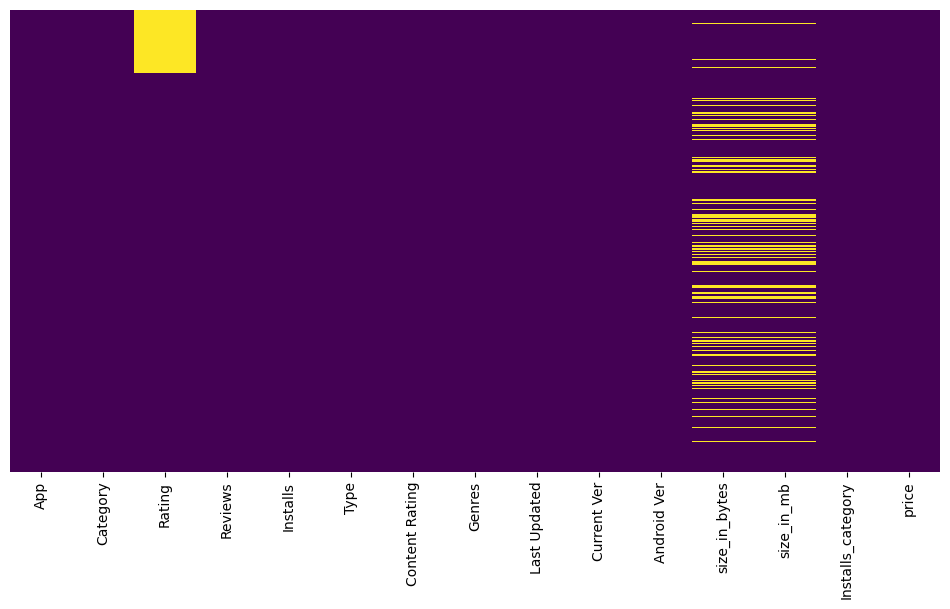

In [220]:
# make a figure size
plt.figure( figsize=(12, 6))
#plot the null values in each column
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')

Text(0.5, 1.0, 'Percentage of Missing Values in each Column')

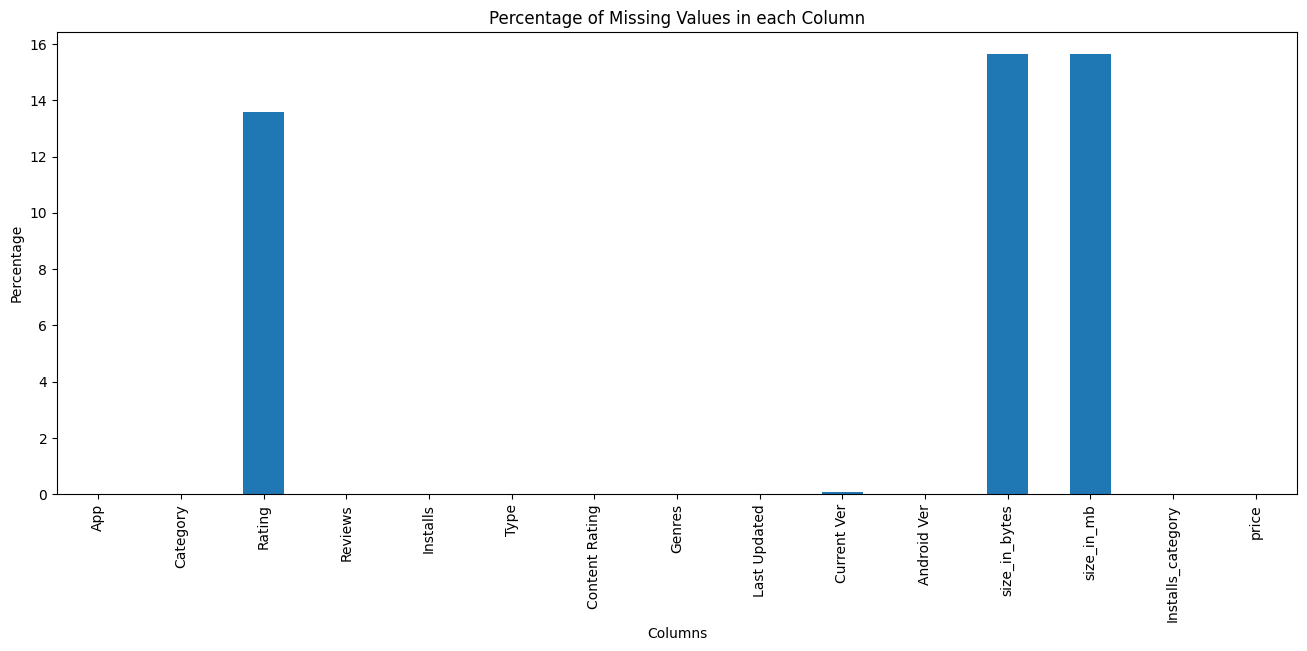

In [221]:

# make figure size
plt.figure(figsize=(16, 6))
# plot the null values by their percentage in each column
missing_percentage = df.isnull().sum()/len(df)*100
missing_percentage.plot(kind='bar')
# add the labels
plt.xlabel('Columns')
plt.ylabel('Percentage')
plt.title('Percentage of Missing Values in each Column')

Let's plot the missing values other than 'Rating', 'Size_in_bytes' and 'Size_in_Mb' column

We have missing percentage columns other than rating having less than one percent of missing values, we will plot them as follows:

Text(0.5, 1.0, 'Percentage of Missing Values in each Column without Rating column')

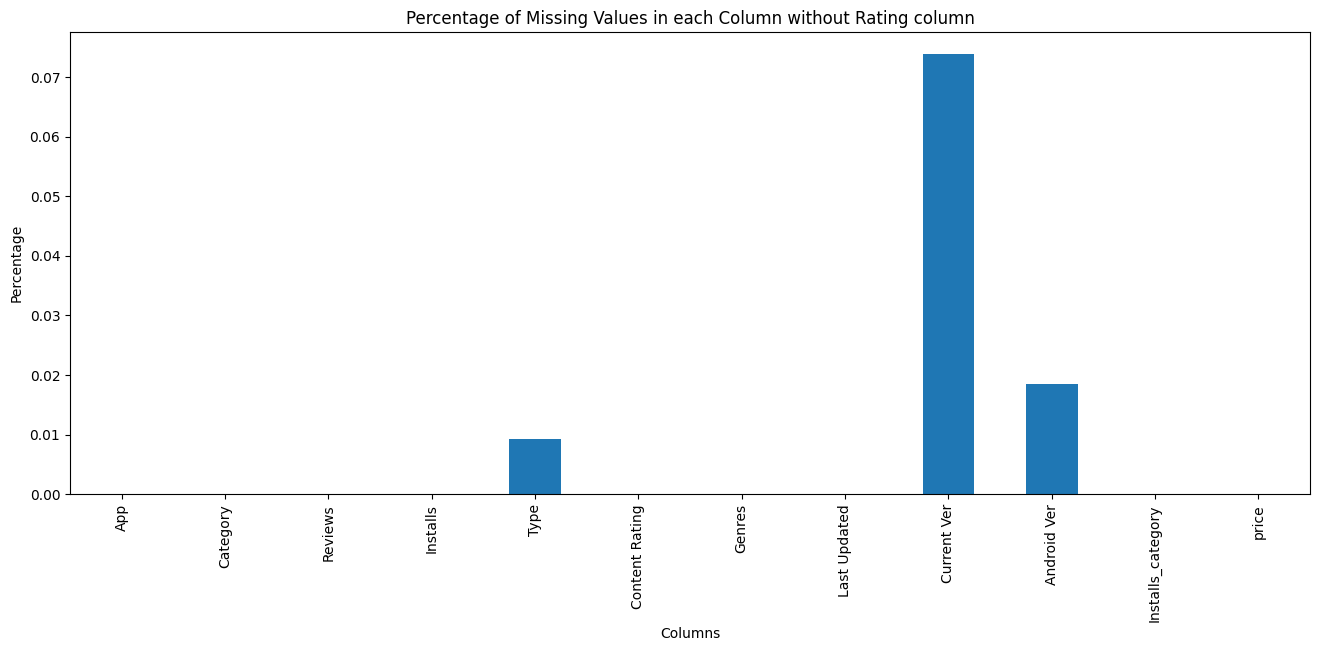

In [223]:
plt.figure(figsize=(16, 6)) # make figure size
missing_percentage[missing_percentage<1].plot(kind='bar') # plot the null values by their percentage in each column
plt.xlabel('Columns') # add the x-axis labels
plt.ylabel('Percentage') # add the labels for y-axis
plt.title('Percentage of Missing Values in each Column without Rating column')  # add the title for the plot

### Observations:
We have 1695 missing values in the 'Size_in_bytes' and 'Size_in_Mb' columns, which is 15.6% of the total values in the column.

We have 1474 missing values in the 'Rating' column, which is 13.6% of the total values in the column.

We have 8 missing value in the 'Current Ver' column, which is 0.07% of the total values in the column.

We have 2 missing values in the 'Android Ver' column, which is 0.01% of the total values in the column.
____
#### 2.3. Dealing with the missing values
We can not impute the Rating column as is is directly linked with the installation column.
To test this Hypothesis we need to plot the Rating column with the Installs and Size columns and statistically test it using pearson correlation test.
___
Let's run the correlations

In [225]:
df.describe()

,Rating,Reviews,Installs,size_in_bytes,size_in_mb,price
count,9365.000000,1.083900e+04,1.083900e+04,9.144000e+03,9.144000e+03,10839.000000
mean,4.191703,4.441858e+05,1.546530e+07,2.256280e+07,2.256280e+07,1.027463
std,0.515220,2.927894e+06,8.503322e+07,2.368725e+07,2.368725e+07,15.950436
min,1.000000,0.000000e+00,0.000000e+00,8.704000e+03,8.704000e+03,0.000000
25%,4.000000,3.800000e+01,1.000000e+03,5.138022e+06,5.138022e+06,0.000000
50%,4.300000,2.094000e+03,1.000000e+05,1.363149e+07,1.363149e+07,0.000000
75%,4.500000,5.464400e+04,5.000000e+06,3.145728e+07,3.145728e+07,0.000000
max,5.000000,7.815831e+07,1.000000e+09,1.048576e+08,1.048576e+08,400.000000


<Axes: >

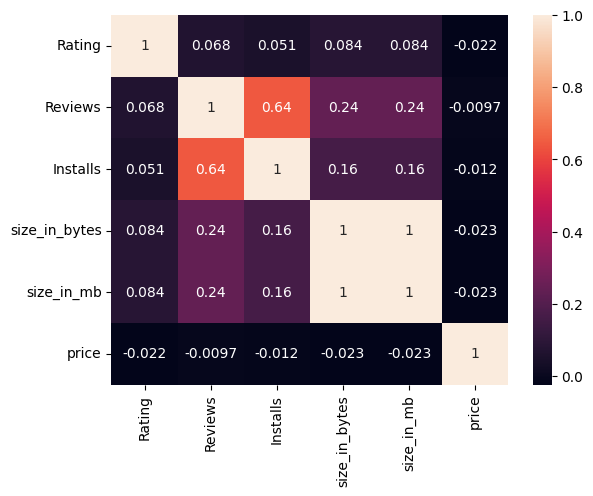

In [231]:
# make the heatmap for checking coorelation of numeric columns
plt.Figure(figsize=( 14, 6))
numeric_cols = ['Rating', 'Reviews', 'Installs', 'size_in_bytes', 'size_in_mb', 'price'] # make a numeric column list
sns.heatmap(df[numeric_cols].corr(), annot=True) # plot the correlation matrix

In [233]:
# we can calculate the pearson correlation coefficient using scipy as well as follows

# this is to install scipy if you have not done it before
# pip install scipy 
from scipy import stats

# remove rows containing NaN or infinite values (Important to calculate Pearson's R)
df_clean = df.dropna()

# calculate Pearson's R between Rating and Installs
pearson_r, _ = stats.pearsonr(df_clean['Reviews'], df_clean['Installs'])
print(f"Pearson's R between Reviews and Installs: {pearson_r:.4f}")

Pearson's R between Reviews and Installs: 0.6262


___
###  Observations
Lighter color shows the high correlation and darker color shows the low correlation

We can see that the Reviews column has a high correlation with the Installs column, which is 0.64 according to corr(). Which is quite good.

This shows that the more the reviews the more the installs are for one app. If in any case we need to impute reviews we have to think of number of install.
If we have an ap with 2 installs and we imputer the reviews with 1000 or via average reviews then it will be wrong.

Installs is slightly correlated with Size_in_Mb or Size_in_bytes , which is 0.16, this also shows us the importance of size and Installs. But we can not depend on it as the Peason correlation is very low.
___
Before going ahead, let's remove the rows with missing values in the Current Ver, Android Ver, Category, Type and Genres columns, as they are very less in number and will not affect our analysis.

In [234]:

# length before removing null values
print(f"Length of the dataframe before removing null values: {len(df)}")

Length of the dataframe before removing null values: 10839


In [235]:

# remove the rows having null values in the 'Current Ver', 'Android Ver', 'Category', 'Type' and 'Genres' column
df.dropna(subset=['Current Ver', 'Android Ver', 'Category', 'Type', 'Genres'], inplace=True)

In [236]:

# length after removing null values
print(f"Length of the dataframe after removing null values: {len(df)}")

Length of the dataframe after removing null values: 10828


*   We have removed 12 rows having null values in the Current Ver, Android Ver, Category, Type and Genres columns.

In [237]:
# let's check the null values again
df.isnull().sum().sort_values(ascending=False)


size_in_mb           1694
size_in_bytes        1694
Rating               1469
Reviews                 0
Installs                0
App                     0
Category                0
Content Rating          0
Type                    0
Genres                  0
Last Updated            0
Android Ver             0
Current Ver             0
Installs_category       0
price                   0
dtype: int64

___
#### Observations
*   Only Rating and Size_in_bytes or Size_in_Mb columns are left with missing values.
    *   We know that we have to be carefull while deadling with Rating column, as it is directly linked with the Installs column.
    *   In Size columns we already know about Varies with device values, which we have converted into null values, we do not need to impute at the moment, as every app has different size and nobody can predict that as nearly as possible.
___

In [238]:
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Installs', 'Type',
       'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver', 'size_in_bytes', 'size_in_mb', 'Installs_category',
       'price'],
      dtype='object')

In [239]:
# use groupby function to find the trend of Rating in each Installs_category
df.groupby('Installs_category')['Rating'].describe()

,count,mean,std,min,25%,50%,75%,max
Installs_category,,,,,,,,
no,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
very low,81.0,4.637037,0.845199,1.0,4.8,5.0,5.0,5.0
low,1278.0,4.170970,0.825605,1.0,3.8,4.4,4.8,5.0
Moderate,1440.0,4.035417,0.604428,1.4,3.8,4.2,4.5,5.0
More than moderate,1616.0,4.093255,0.505619,1.6,3.9,4.2,4.5,4.9
High,2113.0,4.207525,0.376594,1.8,4.0,4.3,4.5,4.9
Very High,2701.0,4.312625,0.275600,2.0,4.2,4.4,4.5,4.9
Top Notch,130.0,4.309231,0.186126,3.7,4.2,4.3,4.4,4.7


In [241]:
df['Rating'].isnull().sum()

np.int64(1469)

In [243]:
df['Installs_category'].loc[df['Rating'].isnull()].value_counts()

Installs_category
low                   880
very low              453
Moderate               88
More than moderate     31
no                     14
High                    3
Very High               0
Top Notch               0
Name: count, dtype: int64

In [262]:
df.isnull().sum().sort_values(ascending=False)

size_in_mb           1694
size_in_bytes        1694
Rating                 14
Reviews                 0
Installs                0
App                     0
Category                0
Content Rating          0
Type                    0
Genres                  0
Last Updated            0
Android Ver             0
Current Ver             0
Installs_category       0
price                   0
dtype: int64

In [ ]:
# Fill missing 'Rating' values with the mean 'Rating' for their corresponding 'Installs_category'
df['Rating'] = df['Rating'].fillna(df.groupby('Installs_category')['Rating'].transform('mean'))


In [263]:
df['Rating'].isnull().sum()  # Should be 0 if all missing values were filled


np.int64(14)

### Observation 
*    now i filled the missing values in rating column with its group wise mean.
*   impute all missing values just ramaining 14 missing values which is not installed that dose not rate   

In [264]:
# in which Install_category the Rating has NaN values
df['Installs_category'].loc[df['Reviews'].isnull()].value_counts()

Installs_category
no                    0
very low              0
low                   0
Moderate              0
More than moderate    0
High                  0
Very High             0
Top Notch             0
Name: count, dtype: int64

<Axes: xlabel='Installs_category', ylabel='Reviews'>

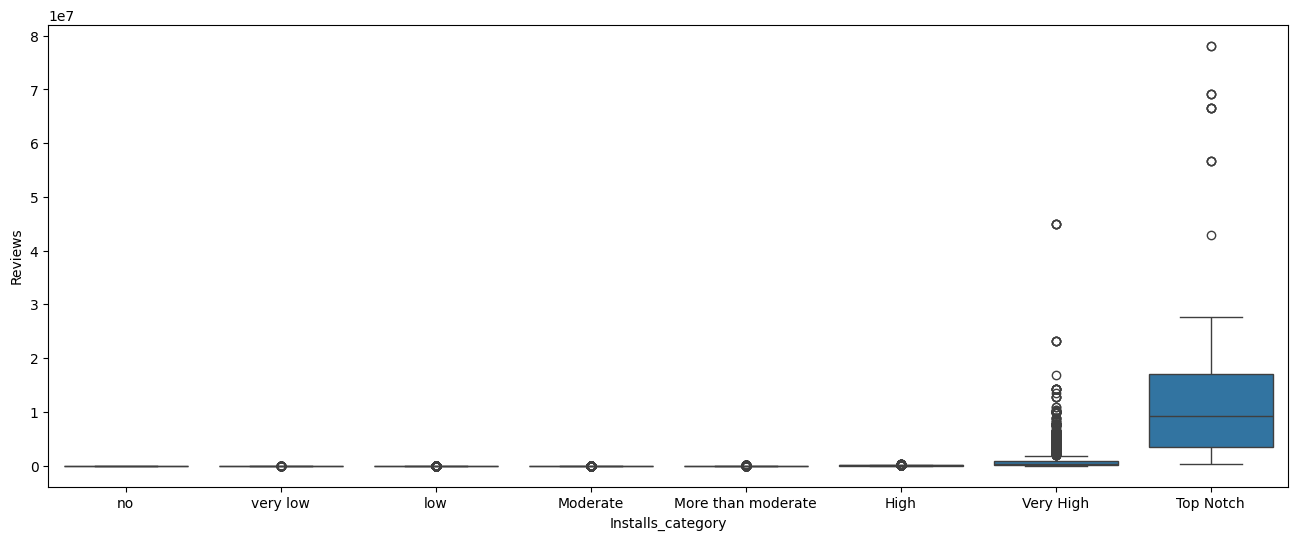

In [265]:
# let's plot the same plots for Reviews column as well
plt.figure(figsize=(16, 6)) # make figure size
sns.boxplot(x='Installs_category', y= 'Reviews', data=df) # plot the boxplot

*   The data looks really imbalance, let's normalize the data using log transformation

<Axes: xlabel='Installs_category', ylabel='Reviews'>

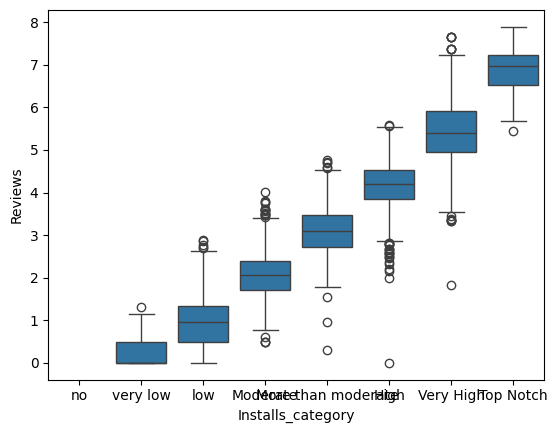

In [271]:
plt.Figure(figsize= (16, 6) )
sns.boxplot(x='Installs_category', y =np.log10(df['Reviews']), data=df)

<Axes: xlabel='Rating', ylabel='Reviews'>

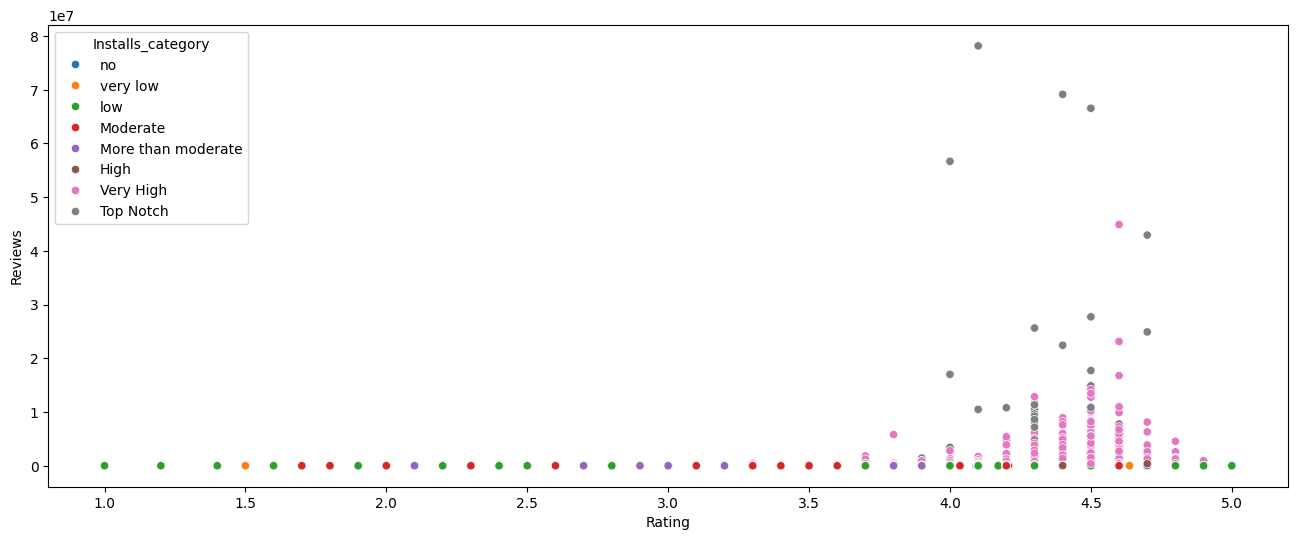

In [272]:
# Draw a scatter plot between Rating, Reviews and Installs
plt.figure(figsize=(16, 6)) # make figure size
sns.scatterplot(x='Rating', y='Reviews', hue='Installs_category', data=df) # plot the scatter plot

*  It doesn't show any trend, because, you should know that Rating is a categorical variable (Ordinal) and Reviews is a continuous variable, therefore, we can not plot them together.

Let's try with Reviews and Installs


<Axes: xlabel='Reviews', ylabel='Installs'>

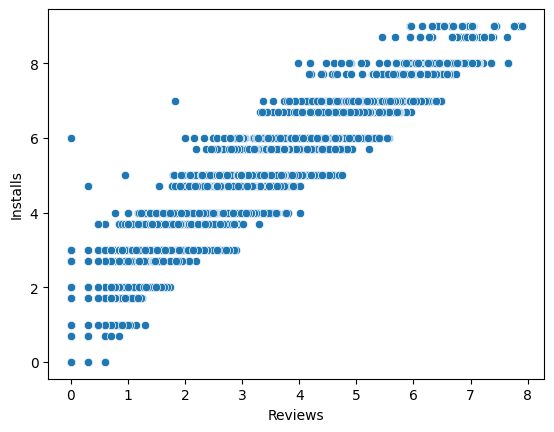

In [274]:
plt.Figure(figsize=(16, 6))
sns.scatterplot(x=np.log10(df['Reviews']), y = np.log10(df['Installs']), data=df)

<Figure size 1600x600 with 0 Axes>

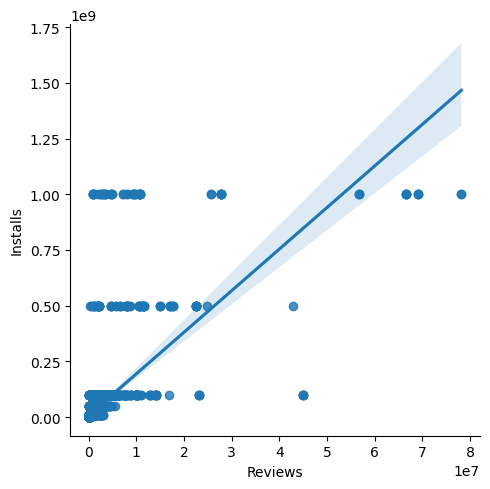

In [ ]:
# plot reviews and installs in a scatter plot with trend line
plt.figure(figsize=(16, 6)) # make figure size
sns.l   mplot(x='Reviews', y='Installs', data=df) # plot the scatter plot with trend line

*   Here, we can see a nice trend, which shows that number of Reviews increases with the number of Installs, which is quite obvious.
___

### Observation

    -We can see that most of the null values from Rating column are no - Moderate Installation apps, which make sense that if the app has less installations, it has less Rating and review.

*   But wait, we have to check for the duplicates as well, as they can affect our analysis.
### 2.3. Duplicates

*   Removing duplicates is one of the most important part of the data wrangling process, we must remove the duplicates in order to get the correct insights from the data.
If you do not remove duplicates from a dataset, it can lead to incorrect insights and analysis.

*    Duplicates can skew statistical measures such as mean, median, and standard deviation, and can also lead to over-representation of certain data points.
It is important to remove duplicates to ensure the accuracy and reliability of your data analysis.

In [276]:
df.duplicated().sum()

np.int64(483)

In [280]:
df['App'].duplicated().sum()

np.int64(1181)

*   Oops! we have 1181 dupicate app names
*   Can we find a column which can help us to remove the duplicates?

let's check for number of duplicates in each column using a for loop and printing the output

In [ ]:
for col in df.columns:
    print(f"the number of duplicates in {col} are : {df[col].duplicated().sum()}")

the number of duplicates in App are : 1181
the number of duplicates in Category are : 10795
the number of duplicates in Rating are : 10783
the number of duplicates in Reviews are : 4830
the number of duplicates in Installs are : 10808
the number of duplicates in Type are : 10826
the number of duplicates in Content Rating are : 10822
the number of duplicates in Genres are : 10709
the number of duplicates in Last Updated are : 9452
the number of duplicates in Current Ver are : 7997
the number of duplicates in Android Ver are : 10795
the number of duplicates in size_in_bytes are : 10372
the number of duplicates in size_in_mb are : 10372
the number of duplicates in Installs_category are : 10820
the number of duplicates in price are : 10736


In [293]:
df['Category'].duplicated().sum()

np.int64(10795)

*   Find and watch all duplicates if they are real!

In [ ]:
# find and check duplicate values and sort them in alpha betically
df[df['App'].duplicated(keep=False)].sort_values(by='App')

,App,Category,Rating,Reviews,Installs,Type,Content Rating,Genres,Last Updated,Current Ver,Android Ver,size_in_bytes,size_in_mb,Installs_category,price
8354,10 Best Foods for You,HEALTH_AND_FITNESS,4.0,2490,500000.0,Free,Everyone 10+,Health & Fitness,"February 17, 2017",1.9,2.3.3 and up,3984588.8,3984588.8,High,0.00
8356,10 Best Foods for You,HEALTH_AND_FITNESS,4.0,2490,500000.0,Free,Everyone 10+,Health & Fitness,"February 17, 2017",1.9,2.3.3 and up,3984588.8,3984588.8,High,0.00
2214,1800 Contacts - Lens Store,MEDICAL,4.7,23160,1000000.0,Free,Everyone,Medical,"July 27, 2018",7.4.1,5.0 and up,27262976.0,27262976.0,High,0.00
2226,1800 Contacts - Lens Store,MEDICAL,4.7,23160,1000000.0,Free,Everyone,Medical,"July 27, 2018",7.4.1,5.0 and up,27262976.0,27262976.0,High,0.00
4752,2017 EMRA Antibiotic Guide,MEDICAL,4.4,12,1000.0,Paid,Everyone,Medical,"January 27, 2017",1.0.5,4.0.3 and up,3984588.8,3984588.8,low,16.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6950,trivago: Hotels & Travel,TRAVEL_AND_LOCAL,4.2,219848,50000000.0,Free,Everyone,Travel & Local,"August 2, 2018",Varies with device,Varies with device,NaN,NaN,Very High,0.00
6957,trivago: Hotels & Travel,TRAVEL_AND_LOCAL,4.2,219848,50000000.0,Free,Everyone,Travel & Local,"August 2, 2018",Varies with device,Varies with device,NaN,NaN,Very High,0.00
6949,trivago: Hotels & Travel,TRAVEL_AND_LOCAL,4.2,219848,50000000.0,Free,Everyone,Travel & Local,"August 2, 2018",Varies with device,Varies with device,NaN,NaN,Very High,0.00
7016,wetter.com - Weather and Radar,WEATHER,4.2,189313,10000000.0,Free,Everyone,Weather,"August 6, 2018",Varies with device,Varies with device,39845888.0,39845888.0,Very High,0.00


In [302]:
# remove duplicate values
df.drop_duplicates(inplace=True)

In [ ]:
# verify this 
df.duplicated().sum()

np.int64(0)

#### Now, i remove this 483 duplicate rows in our dataset


### 3. Insights from Data

### 3.1. Which category has the highest number of apps?

In [306]:
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Installs', 'Type',
       'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver', 'size_in_bytes', 'size_in_mb', 'Installs_category',
       'price'],
      dtype='object')

In [312]:
# which category has highest number of app
df['Category'].value_counts().head(15)

Category
FAMILY                1939
GAME                  1121
TOOLS                  841
BUSINESS               427
MEDICAL                408
PRODUCTIVITY           407
PERSONALIZATION        386
LIFESTYLE              373
COMMUNICATION          366
FINANCE                360
SPORTS                 351
PHOTOGRAPHY            322
HEALTH_AND_FITNESS     306
SOCIAL                 280
NEWS_AND_MAGAZINES     264
Name: count, dtype: int64

### 3.2. Which category has the highest number of installs?

In [324]:
# which category has highest number of installs
df.groupby('Category')['Installs'].sum().sort_values(ascending=False).head(10)

Category
GAME                  3.154402e+10
COMMUNICATION         2.415228e+10
SOCIAL                1.251387e+10
PRODUCTIVITY          1.246309e+10
TOOLS                 1.145227e+10
FAMILY                1.004163e+10
PHOTOGRAPHY           9.721248e+09
TRAVEL_AND_LOCAL      6.361887e+09
VIDEO_PLAYERS         6.222003e+09
NEWS_AND_MAGAZINES    5.393218e+09
Name: Installs, dtype: float64